In [11]:
from pathlib import Path
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

#Load existing dataset from CSV if it exists, otherwise create it from intial data 
#Return both the full dataframe and numpy arrays (x inputs, y outputs)
csv_path = Path("function_2_data.csv")

def load_or_create_dataset():
    if csv_path.exists():
        df = pd.read_csv(csv_path)
    else:
        X_init = np.load('../data/initial_data/function_2/initial_inputs.npy')
        y_init = np.load('../data/initial_data/function_2/initial_outputs.npy')

        df = pd.DataFrame(X_init, columns=['x1', 'x2'])
        df['y'] = y_init
        df.to_csv(csv_path, index=False)

    X = df[['x1', 'x2']].to_numpy()
    y = df['y'].to_numpy()

    return df, X, y

df, X, y = load_or_create_dataset()

#Checking shape of data 
print('Inputs Shape:', X.shape)
print('Outputs Shape:', y.shape)

Inputs Shape: (21, 2)
Outputs Shape: (21,)


In [16]:
#Append newly observed datapoints to existing CSV to keep a single up to date dataset

#Create a function to do this
def append_bo_result(x_new, y_new):
    df = pd.read_csv(csv_path)
    new_row = pd.DataFrame([[x_new[0], x_new[1], y_new]], columns=df.columns)
    df = pd.concat([df, new_row], ignore_index=True)
    df.to_csv(csv_path, index=False)
    return df

#Adding new values to my CSV df
#x_new = [0.715, 0.976]
#y_new = 0.570626585791083

#df = append_bo_result(x_new, y_new)

# Refresh X and y from the updated live dataframe
X = df[['x1', 'x2']].to_numpy()
y = df['y'].to_numpy()

df.tail()

,x1,x2,y
18,0.723846,0.967885,0.639782
19,0.736422,0.943557,0.500463
20,0.711680,0.972452,0.720820
21,0.694659,0.990308,0.584234
22,0.715000,0.976000,0.570627


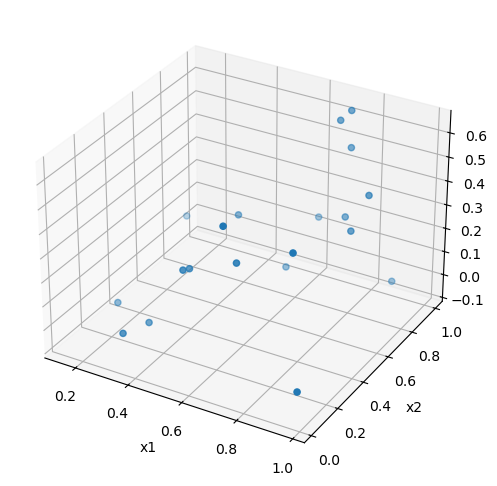

In [20]:
#3D scatter plot of obserevd function values 

#create a figure
fig = plt.figure(figsize=(7,6))

#add a 3D axis to the figure
#111 means 1 row, 1 column, first plot position
ax = fig.add_subplot(111, projection = '3d')

#label the axis
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")

#plot the sampled points 
ax.scatter(df['x1'], df['x2'], df['y'])

plt.show()


In [12]:
#Define GP hyperparameters and make a grid / generate random candidate points for acqusition optimisation
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

#hyperparamters for GP surrogate model and acqusition function 
matern_lengthscale = 0.2
nu = 2.5 #controls bumpiness
noise_assumption = 0.3 
xi = 0.01

#Setting number of random candidate points
n_candidates = 5000 

#Sample uniformly from [0, 1]^2
X_candidates = np.random.rand(n_candidates, 2)


In [14]:
#Fit the GP to current data 

kernel = (C(1.0, (1e-3, 1e3)) * Matern(length_scale=0.2, length_scale_bounds=(1e-3, 5), nu=2.5) 
    + WhiteKernel(noise_level=0.3, noise_level_bounds=(1e-6, 1)))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=0)
gp.fit(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=0.2, nu=2.5) + WhiteKernel(noise_level=0.3),
                         n_restarts_optimizer=5, normalize_y=True,
                         random_state=0)

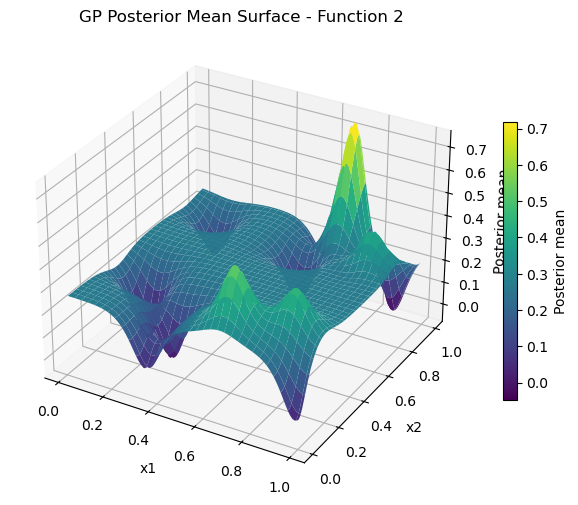

In [16]:
#Prosterior Mean Visualisation 

#create a grid to represent the mean surface 
g= np.linspace(0.01, 0.99, 101)
x1g, x2g = np.meshgrid(g, g)
# Flatten the two grid arrays into long 1D lists
# Stack them together column by column
# Each row is one candidate point: [x1, x2]
X_grid = np.column_stack([x1g.ravel(), x2g.ravel()])

#Use the fitted GP to predict on X_grid
#Not the candidates I will use for optimisation! 
#Instead, it will just give a rough visualisation for the predicted mean at various intervals over this grid 
#Optimisation points are predicted on a random n_candidates 

mu = gp.predict(X_grid)

#Reshape predictions back into grid form 
mu_grid = mu.reshape(x1g.shape)

# Create a new figure (canvas)
fig = plt.figure(figsize=(8, 6))

# Add a 3D axis to the figure
ax = fig.add_subplot(111, projection='3d')

# Plot the GP posterior mean as a smooth surface
# x1g = x-coordinates on the grid
# x2g = y-coordinates on the grid
# mu_grid = predicted height (posterior mean) at each grid point
surf = ax.plot_surface(x1g, x2g, mu_grid, cmap='viridis')

# Label the axes
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Posterior mean")

# Title
ax.set_title("GP Posterior Mean Surface - Function 2")

# Add a colour bar so the colours are easier to interpret
fig.colorbar(surf, ax=ax, shrink=0.6, label="Posterior mean")

# Display the plot
plt.show()



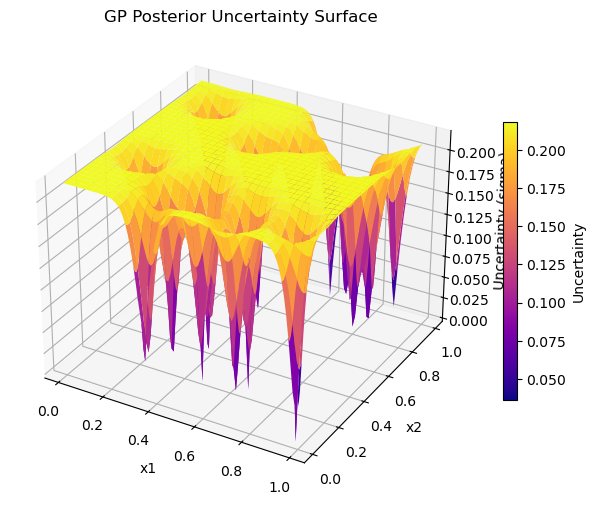

In [18]:
#Plot the uncertainty surface 

# Ask the GP for the uncertainty (standard deviation)
mu, sigma = gp.predict(X_grid, return_std=True)

# Reshape the uncertainty so it matches the 2D grid
sigma_grid = sigma.reshape(x1g.shape)

# Create a new figure
fig = plt.figure(figsize=(8,6))

# Add a 3D axis
ax = fig.add_subplot(111, projection='3d')

# Plot the uncertainty surface
surf = ax.plot_surface(x1g, x2g, sigma_grid, cmap='plasma')

# Label the axes
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Uncertainty (sigma)")

# Title
ax.set_title("GP Posterior Uncertainty Surface")

# Add a colour bar
fig.colorbar(surf, ax=ax, shrink=0.6, label="Uncertainty")

# Show the plot
plt.show()

In [20]:
#Setting up and running acqusition function

from scipy.stats import norm
import numpy as np

#Expected Improvement (Queries 1-4, 10-13)

improvement = mu - y_best - xi
Z = improvement / std
ei = improvement * norm.cdf(Z) + std * norm.pdf(Z)
# Avoid division by zero
std = np.maximum(std, 1e-9)


# Predict mean and standard deviation on candidate points
mu, std = gp.predict(X_candidates, return_std=True)

# Current best observed value
y_best = np.max(y)

# Choose the next query point as the candidate with the highest EI
idx = np.argmax(ei)
x_next = X_candidates[idx]

print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f})")


#UCB 
#mu, std = gp.predict(X_candidates, return_std=True)
# UCB acquisition
#ucb = mu + beta * std
# Choose the next query point as the candidate with the highest UCB
#idx = np.argmax(ucb)
#x_next = X_candidates[idx]
#print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f})")

x_next = (0.694659, 0.990308)


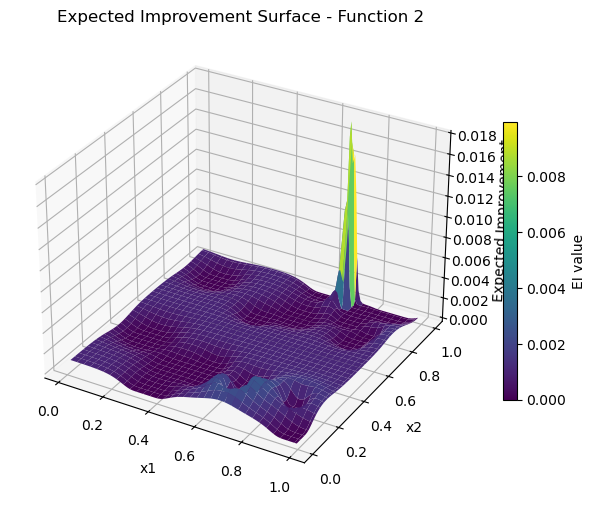

In [22]:
#Aqusition Function Visualisation 

#Creating a grid for visualisation
#Note that the acqusition function for optimisaitions has not used a grid as it is too restrictive
#Grid is used in this case to allow a general shape of the function to be visualised, even if coarse
g = np.linspace(0.01, 0.99, 101)
x1g, x2g = np.meshgrid(g, g)
X_grid = np.column_stack([x1g.ravel(), x2g.ravel()])

# Predict mean and standard deviation on the grid
mu, std = gp.predict(X_grid, return_std=True)

# Compute EI acqusition function on grid and plot

g = np.linspace(0.01, 0.99, 101)
x1g, x2g = np.meshgrid(g, g)
X_grid = np.column_stack([x1g.ravel(), x2g.ravel()])

# Predict mean and standard deviation on the grid
mu, std = gp.predict(X_grid, return_std=True)

# Current best value
y_best = np.max(y)

# EI exploration parameter
xi = 0.03

# Prevent division by zero
std = np.maximum(std, 1e-9)

# Expected Improvement calculation
improvement = mu - y_best - xi
Z = improvement / std
ei = improvement * norm.cdf(Z) + std * norm.pdf(Z)

# Reshape EI values back to grid
ei_grid = ei.reshape(x1g.shape)

# Create figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot EI surface
surf = ax.plot_surface(x1g, x2g, ei_grid, cmap='viridis')

# Labels
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Expected Improvement")

# Title
ax.set_title("Expected Improvement Surface - Function 2")

# Colour bar
fig.colorbar(surf, ax=ax, shrink=0.6, label="EI value")

plt.show()


# Compute UCB acquisition on the grid

#ucb = mu + beta * std
# Reshape back into grid form
#ucb_grid = ucb.reshape(x1g.shape)
# Create a new figure
#fig = plt.figure(figsize=(8, 6))
# Add a 3D axis
#ax = fig.add_subplot(111, projection='3d')
# Plot the acquisition surface
#surf = ax.plot_surface(x1g, x2g, ucb_grid, cmap='viridis')
# Label the axes
#ax.set_xlabel("x1")
#ax.set_ylabel("x2")
#ax.set_zlabel("Acquisition value")
# Add a title
#ax.set_title("UCB Acquisition Surface - Function 2")
# Add a colour bar
#fig.colorbar(surf, ax=ax, shrink=0.6, label="Acquisition value")
# Display the plot
#plt.show()


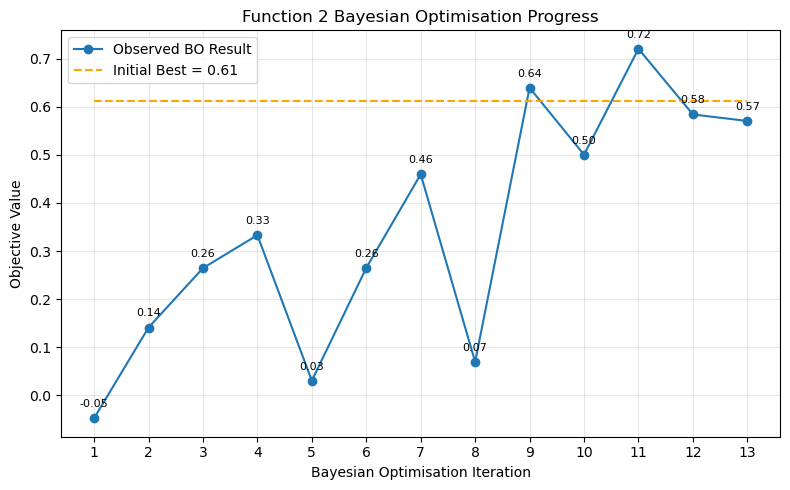

In [18]:
# Plot a graph to track function_2 Bayesian Optimisation progress 

#Intial y_best existing in origional dataset 
INITIAL_BEST_Y = 0.611205  

# Load my live CSV data file 
df_plot = pd.read_csv(csv_path)
df_plot["y"] = pd.to_numeric(df_plot["y"], errors="coerce")

# Select Bayesian Optimisation data from existing dataset and assign them indexes for plotting
bo = df_plot.tail(13).copy()
bo["iteration"] = range(1, len(bo) + 1)

x = bo["iteration"]
y = bo["y"]

# Flat baseline using your manual value
baseline = np.full(len(y), INITIAL_BEST_Y)

# Plot the graph 
plt.figure(figsize=(8, 5))

plt.plot(x, y, marker="o", label="Observed BO Result")
plt.plot(x, baseline, linestyle="--", color="orange", label=f"Initial Best = {INITIAL_BEST_Y:.2f}")

# Labels on points
for i, val in zip(x, y):
    plt.annotate(f"{val:.2f}", (i, val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.xlabel("Bayesian Optimisation Iteration")
plt.ylabel("Objective Value")
plt.title("Function 2 Bayesian Optimisation Progress")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("function_2_bo_progress.png", dpi=300, bbox_inches="tight")
plt.show()